## Import libraries

In [687]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))
np.set_printoptions(suppress=True)

## Import dataset

In [688]:
df_customers = pd.read_csv('dataset/customers.csv')
df_loans = pd.read_csv('dataset/loans.csv')
df_bureau = pd.read_csv('dataset/bureau_data.csv')

In [689]:
df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [690]:
df = pd.merge(df_customers, df_loans, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.00,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.00,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.00,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.00,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.00,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [691]:
df = pd.merge(df, df_bureau, on='cust_id')
print(f'The number of Rows: {df.shape[0]}, Cols: {df.shape[1]}')
df.head()

The number of Rows: 50000, Cols: 33


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [692]:
df['default'] = df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

## Train Test Split ( To avoid train test contamination)

In [693]:
target = 'default'
X = df.drop(target, axis='columns')
y = df[target]

X_training, X_test, y_training, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

In [694]:
df_train = pd.concat([X_training, y_training], axis='columns')
df_test = pd.concat([X_test, y_test], axis='columns')

In [695]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-06-18,2020-07-07,3,0,76,0,0,8,87,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-11-12,2020-12-07,1,2,60,0,0,1,71,0


In [696]:
df_train.shape, df_test.shape

((37500, 33), (12500, 33))

## Data Cleaning

### Handle NA and duplicate values

In [697]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [698]:
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [699]:
mode_residence = df_train.residence_type.mode()[0]
mode_residence

'Owned'

In [700]:
df_train.residence_type.fillna(mode_residence, inplace=True)
df_train.residence_type.unique()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30876\2089477585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train.residence_type.fillna(mode_residence, inplace=True)


array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [701]:
# Apply same step on test set
df_test.residence_type.fillna(mode_residence, inplace=True)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30876\3946370845.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test.residence_type.fillna(mode_residence, inplace=True)


In [702]:
df_train.duplicated().sum()

np.int64(0)

In [703]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

### Columns Analysis

In [704]:
numeric_columns = ['age', 'income', 'number_of_dependants', 'years_at_current_address', 'sanction_amount', 'loan_amount', 
                'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months', 'principal_outstanding', 
                'bank_balance_at_application', 'number_of_open_accounts', 'number_of_closed_accounts', 
                'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

categorical_columns = ['gender', 'marital_status', 'employment_status', 'residence_type', 'city', 'state', 
                    'zipcode', 'loan_purpose', 'loan_type', 'default']

### Numeric columns

In [705]:
import math

def boxPlot(df, cols):
    n = len(cols)
    rows = math.ceil(n / 4)  # number of rows needed
    fig, axes = plt.subplots(rows, 4, figsize=(15, 5*rows))  # grid of plots
    
    # Flatten axes array for easy iteration
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f'Box plot for {col}')
    
    # Hide unused axes if cols not multiple of 3
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()


def histPlot(df, cols):
    n = len(cols)
    rows = math.ceil(n / 4)  # number of rows needed
    fig, axes = plt.subplots(rows, 4, figsize=(20, 5*rows))  # grid of plots (4 per row)
    
    # Flatten axes array for easy iteration
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Histogram for {col}')
    
    # Hide unused axes if cols not multiple of 4
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

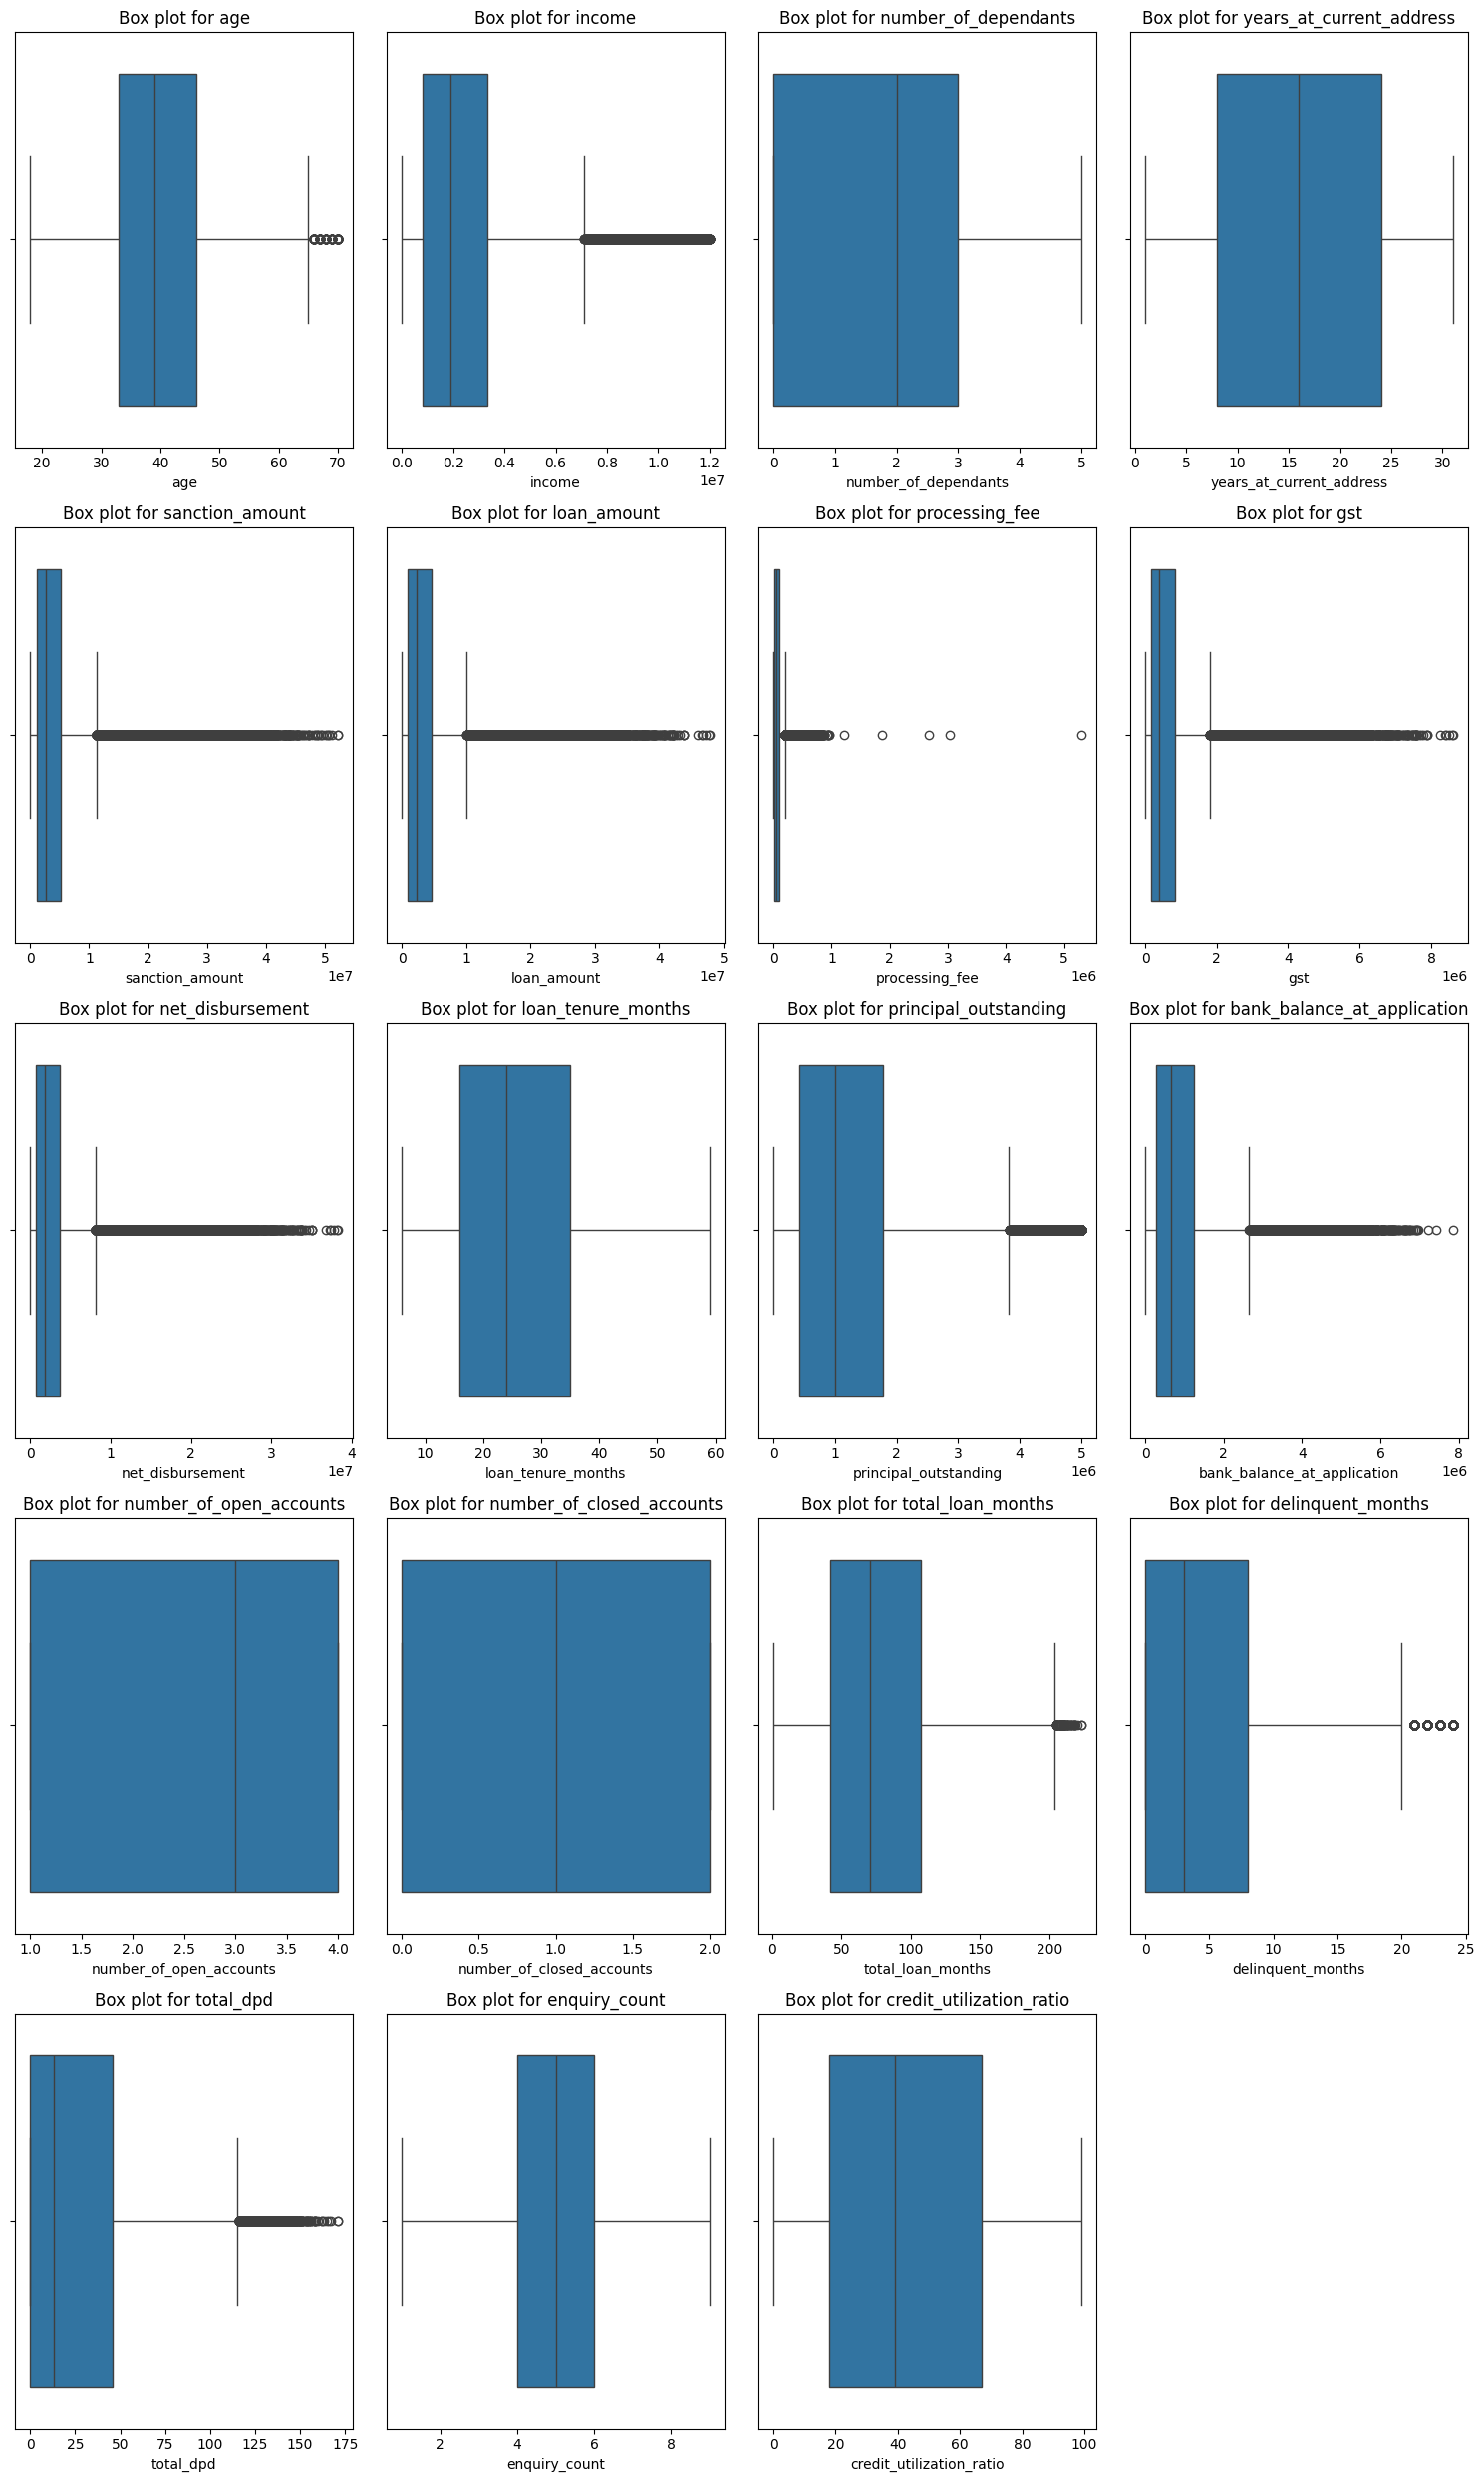

In [706]:
boxPlot(df_train, numeric_columns)

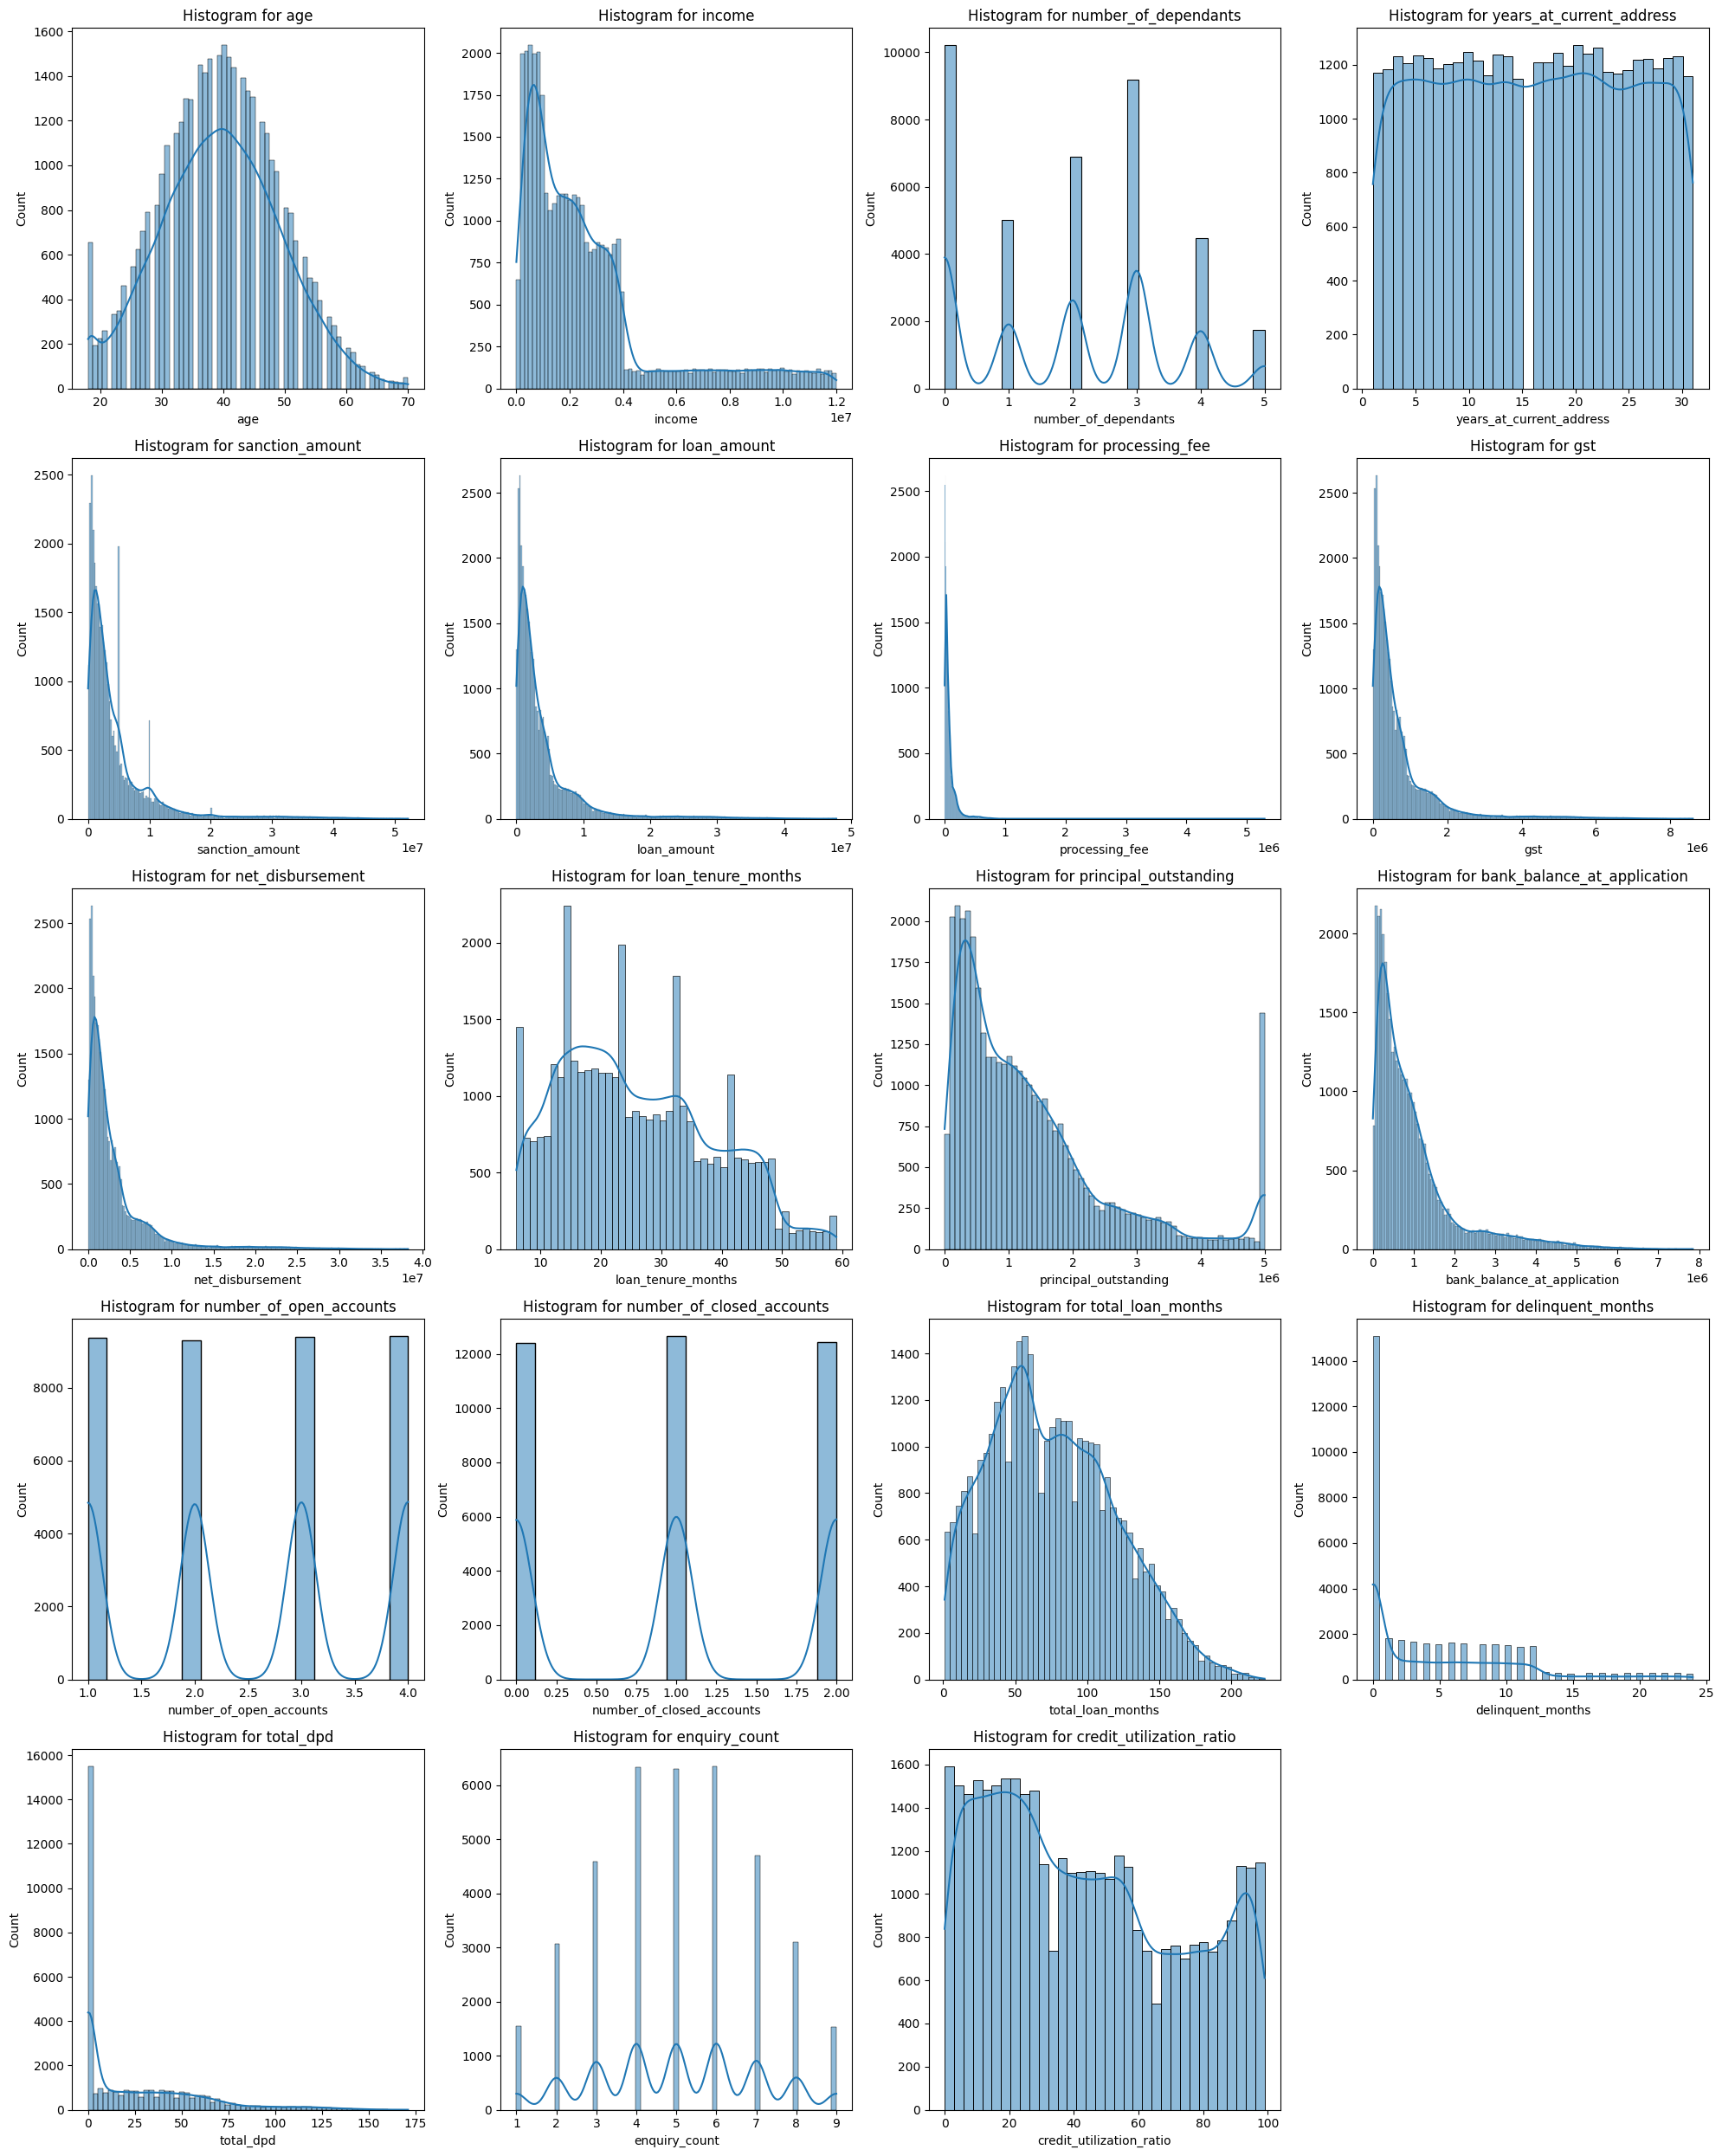

In [707]:
histPlot(df_train, numeric_columns)

In [708]:
df_train.processing_fee.describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

In [631]:
df_train[df_train.processing_fee > df_train.loan_amount][['loan_amount', 'processing_fee']]

,loan_amount,processing_fee
23981,2234000,2669791.02
28174,966000,1214492.67
47089,1738000,1858964.77
29305,2616000,3036378.01
9898,3626000,5293543.52


In [632]:
processing_fee_threshold = 3 / 100

df_train[df_train.processing_fee / df_train.loan_amount > processing_fee_threshold]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
23981,C23982,33,F,Single,Self-Employed,1790000,0,Rented,7,Kolkata,...,2021-12-15,2022-01-14,4,2,154,9,31,6,26,0
28174,C28175,36,F,Single,Self-Employed,1123000,1,Rented,31,Hyderabad,...,2022-05-18,2022-06-05,3,0,111,8,41,3,62,0
47089,C47090,37,M,Married,Self-Employed,1892000,2,Rented,13,Jaipur,...,2024-04-07,2024-04-15,3,0,112,5,33,3,32,0
29305,C29306,52,M,Married,Self-Employed,3839000,2,Owned,11,Delhi,...,2022-06-28,2022-07-21,2,2,42,11,65,3,2,0
9898,C09899,56,M,Married,Self-Employed,8948000,5,Owned,16,Ahmedabad,...,2020-07-19,2020-08-11,2,1,51,1,5,3,92,0


In [633]:
# condition: col1 / col2 > threshold
mask = df_train["processing_fee"] / df_train["loan_amount"] > processing_fee_threshold  

# replace col1 with threshold% of col2 for those rows
df_train.loc[mask, "processing_fee"] = processing_fee_threshold * df_train.loc[mask, "loan_amount"]

In [634]:
df_train[df_train.processing_fee / df_train.loan_amount > processing_fee_threshold].shape

(0, 33)

In [635]:
#Apply same step on test set
# condition: col1 / col2 > threshold
mask = df_test["processing_fee"] / df_test["loan_amount"] > processing_fee_threshold  

# replace col1 with threshold% of col2 for those rows
df_test.loc[mask, "processing_fee"] = processing_fee_threshold * df_test.loc[mask, "loan_amount"]
df_test[df_test.processing_fee / df_test.loan_amount > processing_fee_threshold].shape

(0, 33)

### Categorical columns

In [636]:
for col in categorical_columns:
    print(f'{col}', end=': ')
    print(df_train[col].unique())

gender: ['M' 'F']
marital_status: ['Married' 'Single']
employment_status: ['Self-Employed' 'Salaried']
residence_type: ['Owned' 'Mortgage' 'Rented']
city: ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state: ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode: [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose: ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type: ['Secured' 'Unsecured']
default: [0 1]


In [637]:
df_train['loan_purpose'] = df_train['loan_purpose'].replace('Personaal', 'Personal')
df_train.loan_purpose.unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

In [638]:
#Apply same step on test set

df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal', 'Personal')
df_test.loan_purpose.unique()

array(['Home', 'Education', 'Auto', 'Personal'], dtype=object)

## Exploratory Data Analysis

In [639]:
def kdePlots(df, cols, target = 'default'):
    n = len(cols)
    rows = (n + 3) // 4  # number of rows needed
    fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))  

    axes = axes.flatten()  # make it easy to index

    for i, col in enumerate(cols):
        ax = axes[i]
        sns.kdeplot(df[df[target] == 0][col], fill=True, label='Did not default', ax=ax)
        sns.kdeplot(df[df[target] == 1][col], fill=True, label='Defaulted', ax=ax)
        ax.set_title(f'KDE Plot of {col} by {target}')
        ax.legend()

    # Remove extra axes if cols is not multiple of 4
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

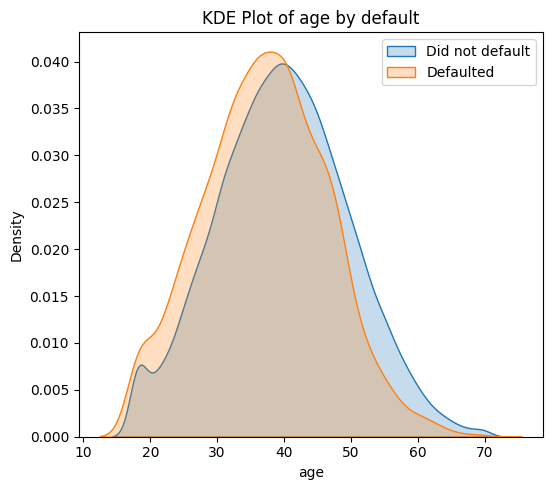

In [640]:
kdePlots(df_train, ['age'], 'default')

Insights
1. Orange graph is a little bit shifted to the left of blue graph which indicates that people with young age are more likely to default

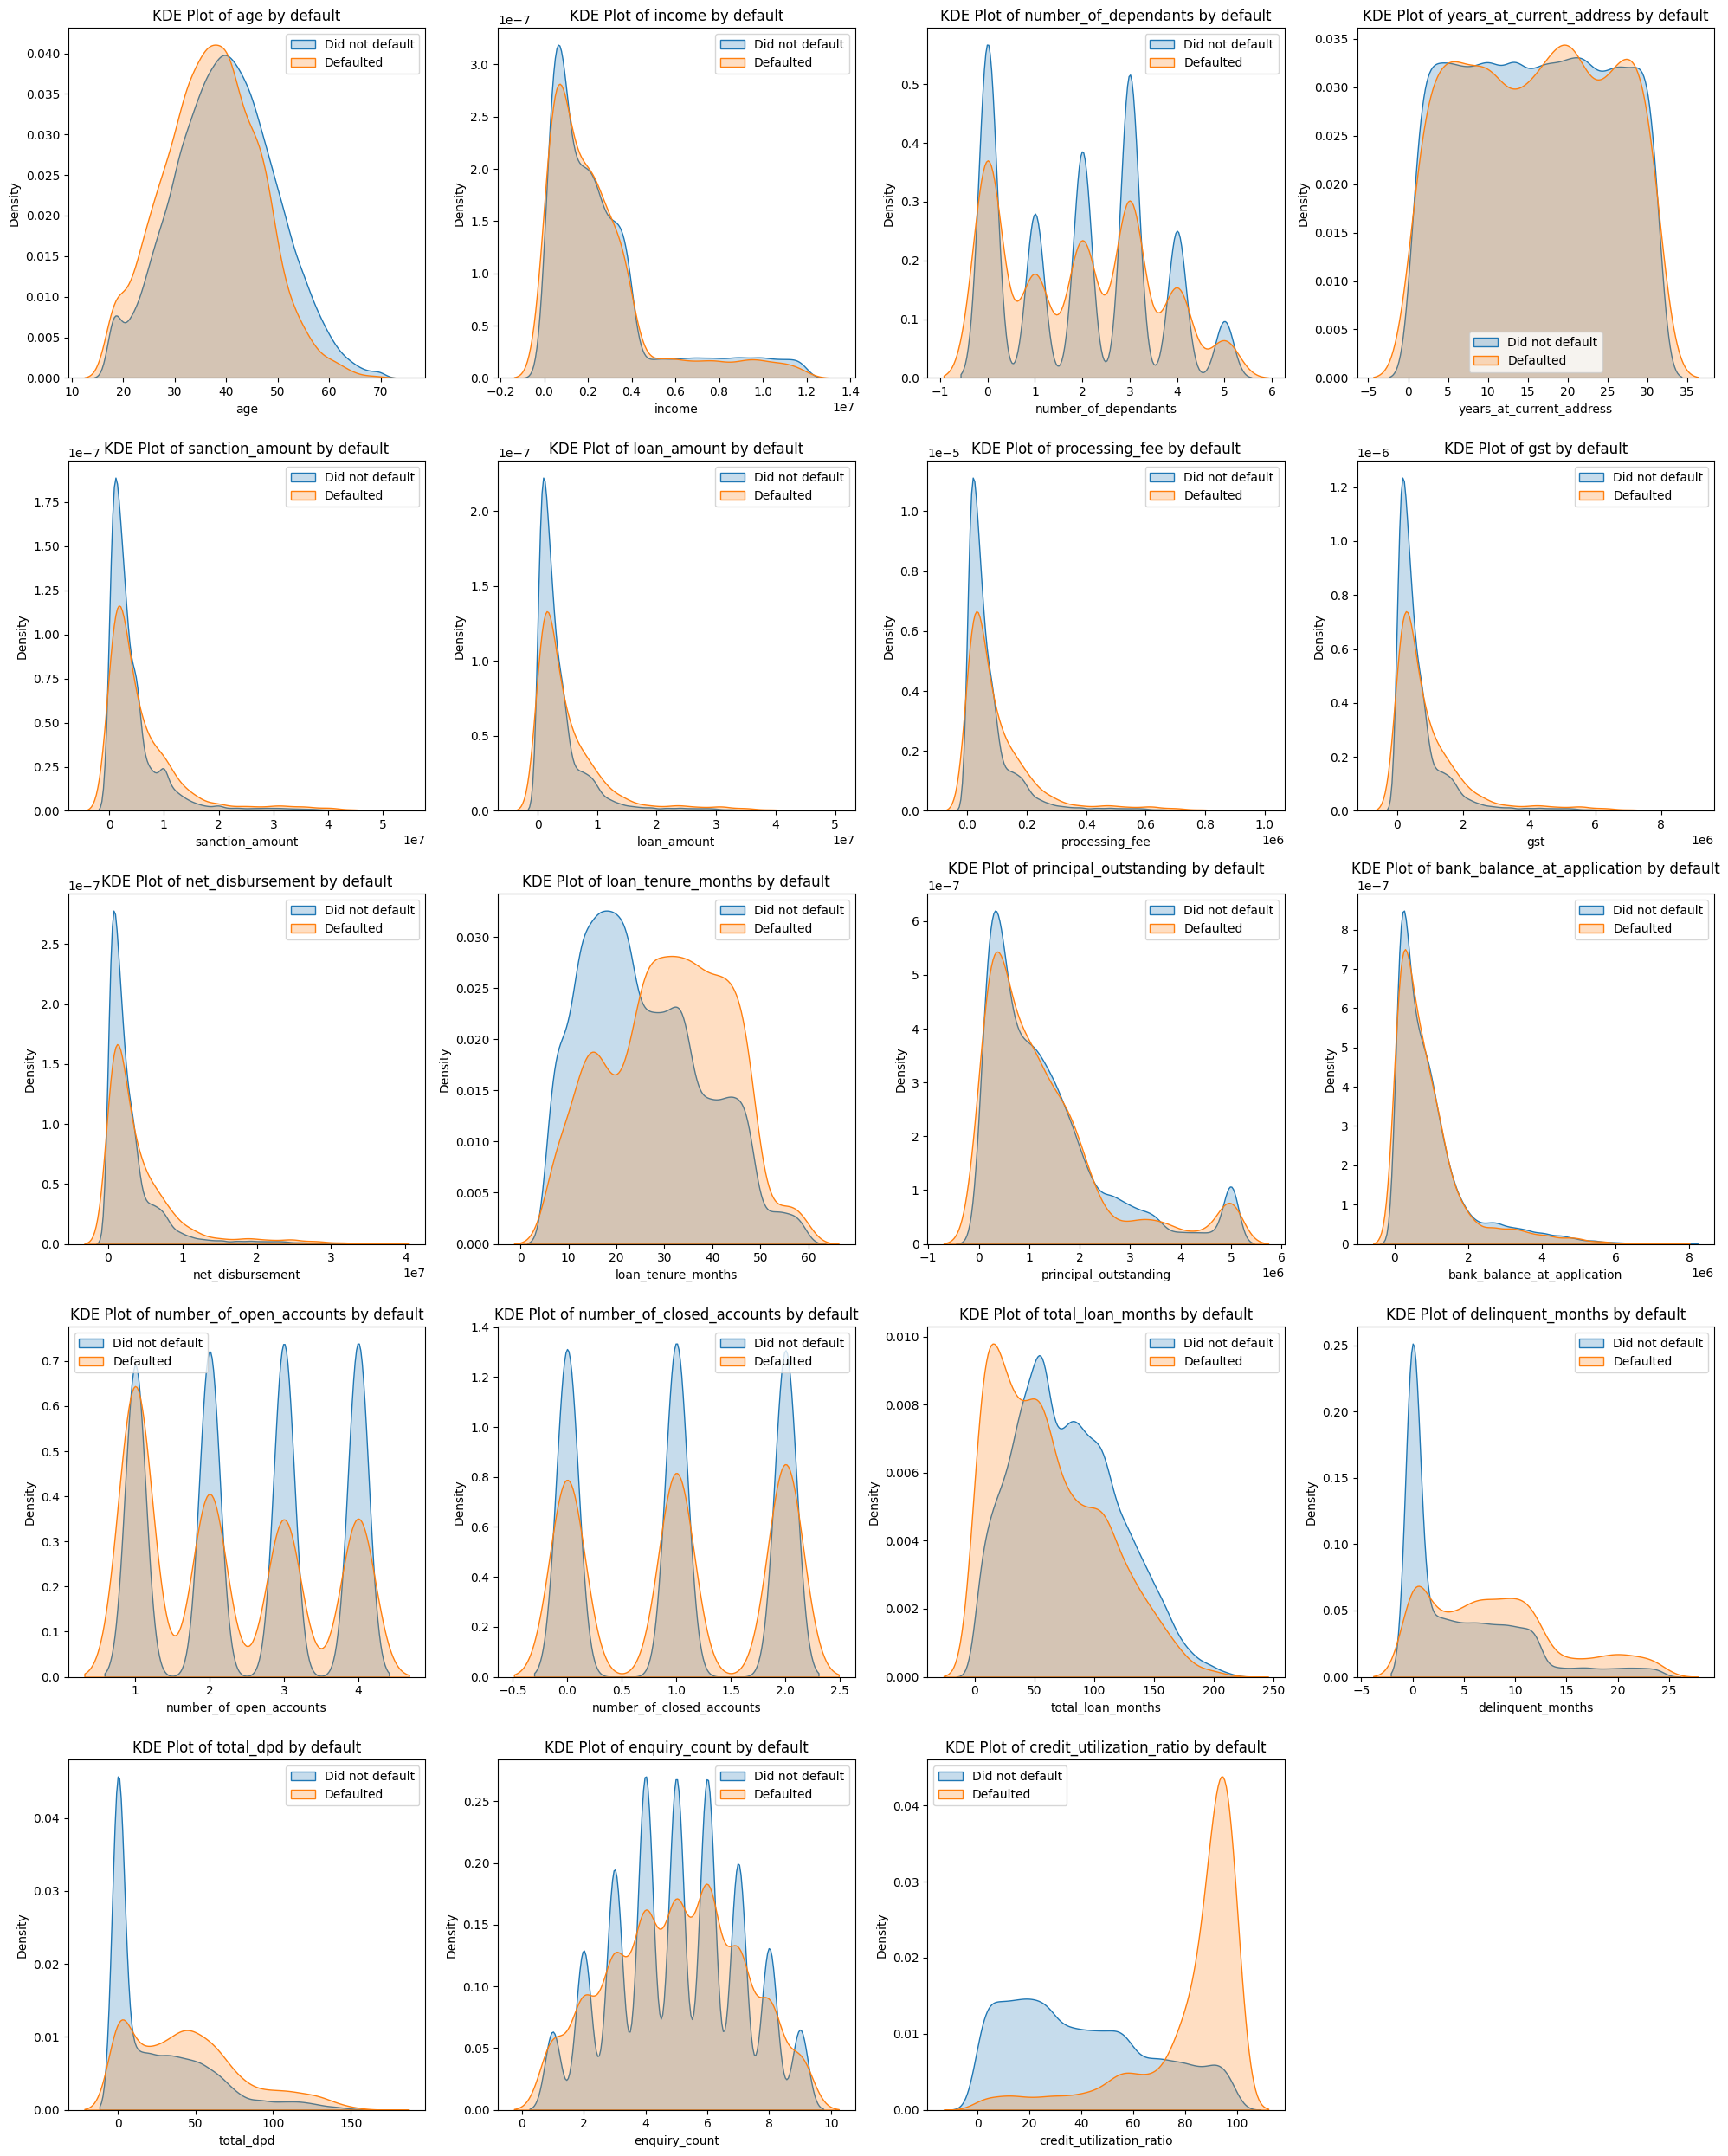

In [641]:
kdePlots(df_train, numeric_columns, 'default')

Insights

1. In columns: loan_tenure_months, delinquet_months, total_dpd, credit_utilization, higher values indicate high likelyhood of becoming a default. Hence these 4 look like strong predictors
2. In remaining columns the distributions to not give any obvious insights
3. Why loan_amount and income did not give any signs of being strong predictors? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable. We will explore more later

## Feature Engineering

### Loan to income ratio

In [642]:
df_train['loan_to_income'] = np.where(df_train['income'] != 0, 
                                    (df_train['loan_amount'] / df_train['income']).round(2), 0)
df_train['loan_to_income'].describe()
# Apply same step on test set
df_test['loan_to_income'] = np.where(df_test['income'] != 0, 
                                    (df_test['loan_amount'] / df_test['income']).round(2), 0)
df_train['loan_to_income'].describe()

count   37500.00
mean        1.56
std         0.97
min         0.00
25%         0.77
50%         1.16
75%         2.46
max         4.57
Name: loan_to_income, dtype: float64

In [643]:
df_train.loan_to_income.isna().sum()

np.int64(0)

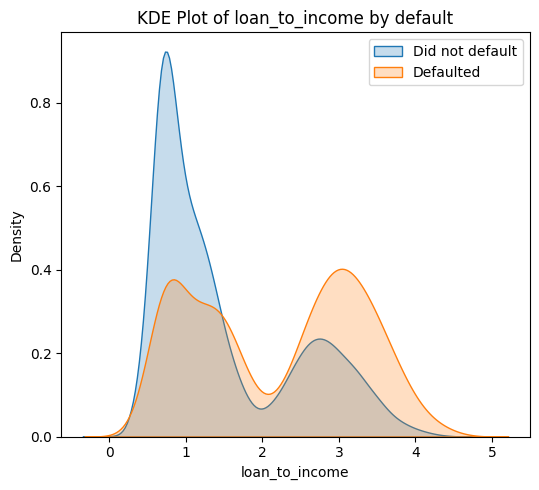

In [644]:
kdePlots(df_train, ['loan_to_income'], 'default')

### Delinquency ratio

In [645]:
df_train['delinquency_ratio'] = round(df_train['delinquent_months'] * 100 / df_train['total_loan_months'], 2)
df_train[['delinquent_months', 'total_loan_months', 'delinquency_ratio']].head()

,delinquent_months,total_loan_months,delinquency_ratio
12746,20,152,13.16
32495,10,160,6.25
43675,12,54,22.22
9040,0,76,0.00
13077,0,60,0.00


In [646]:
df_train.delinquency_ratio.isna().sum()

np.int64(0)

In [647]:
# Apply same step on test set

df_test['delinquency_ratio'] = round(df_test['delinquent_months'] * 100 / df_test['total_loan_months'], 2)

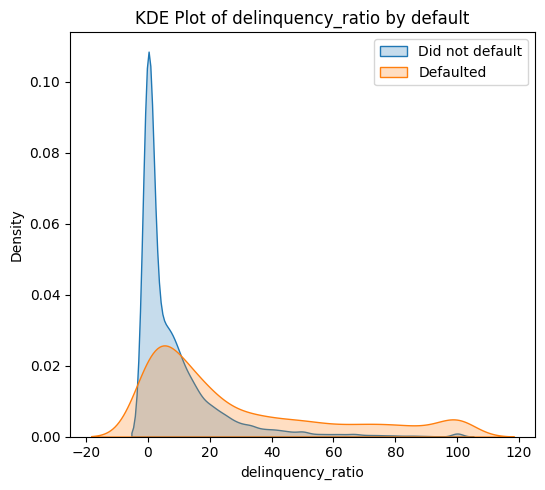

In [648]:
kdePlots(df_train, ['delinquency_ratio'])

### Average DPD per delinquency

In [649]:
df_train['avg_dpd_per_delinquency'] = np.where(df_train['delinquent_months'] != 0, 
                                    (df_train['total_dpd'] / df_train['delinquent_months']).round(2), 0)
df_train['avg_dpd_per_delinquency'].describe()

count   37500.00
mean        3.28
std         2.91
min         0.00
25%         0.00
50%         4.33
75%         5.74
max        10.00
Name: avg_dpd_per_delinquency, dtype: float64

In [650]:
# Apply same step on test set

df_test['avg_dpd_per_delinquency'] = np.where(df_test['delinquent_months'] != 0, 
                                    (df_test['total_dpd'] / df_test['delinquent_months']).round(2), 0)

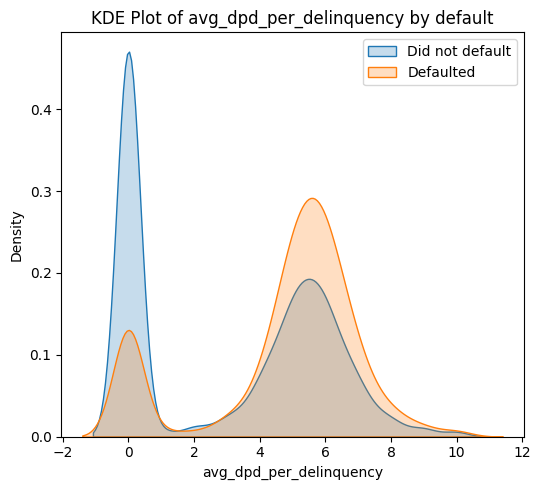

In [651]:
kdePlots(df_train, ['avg_dpd_per_delinquency'])

### Feature Selection

In [652]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [653]:
columns_to_drop = ['cust_id', 'loan_id', 'disbursal_date', 'installment_start_dt', 'loan_amount', 'income',
                    'total_loan_months', 'delinquent_months', 'total_dpd']

In [654]:
df_train.drop(columns_to_drop, axis='columns', inplace=True)
df_test.drop(columns_to_drop, axis='columns', inplace=True)


In [655]:
df_train.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency'],
      dtype='object')

In [656]:
numeric_columns_VIF = ['age', 'number_of_dependants', 'years_at_current_address',
        'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
        'loan_tenure_months', 'principal_outstanding',
        'bank_balance_at_application', 'number_of_open_accounts',
        'number_of_closed_accounts', 'enquiry_count',
        'credit_utilization_ratio', 'loan_to_income',
        'delinquency_ratio', 'avg_dpd_per_delinquency']

numeric_columns_VIF

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

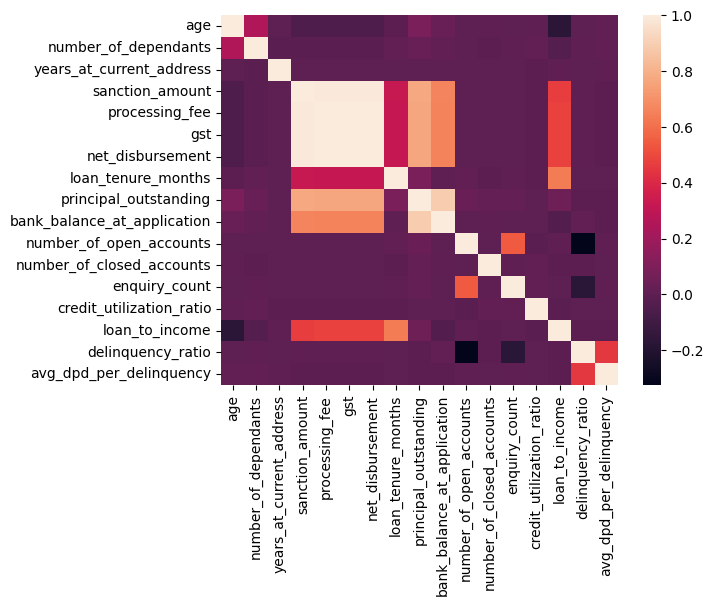

In [657]:
cm = df_train[numeric_columns_VIF].corr()

sns.heatmap(cm)
plt.show()

In [658]:
X_training = df_train.drop(target, axis='columns')
y_training = df_train[target]

X_test = df_test.drop(target, axis='columns')
y_test = df_test[target]

In [659]:
numeric_columns_VIF

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

### VIF

In [660]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [661]:
calculate_vif(X_training[numeric_columns_VIF])

c:\Users\ahmad\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,12.36
1,number_of_dependants,2.78
2,years_at_current_address,3.89
3,sanction_amount,102.17
4,processing_fee,232470.37
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,9.26
8,principal_outstanding,16.85
9,bank_balance_at_application,9.43


In [662]:
def dropCol(df_train, df_test, list_of_cols, col_to_drop):
    # Drop col from train if present
    if col_to_drop in df_train.columns:
        df_train.drop(col_to_drop, axis=1, inplace=True)
    
    # Drop col from test if present
    if col_to_drop in df_test.columns:
        df_test.drop(col_to_drop, axis=1, inplace=True)
    
    # Remove from list if present
    if col_to_drop in list_of_cols:
        list_of_cols.remove(col_to_drop)


In [663]:
dropCol(df_train, df_test, numeric_columns_VIF, 'gst')

In [664]:
calculate_vif(X_training[numeric_columns_VIF])

,Column,VIF
0,age,12.36
1,number_of_dependants,2.78
2,years_at_current_address,3.89
3,sanction_amount,102.17
4,processing_fee,232470.37
5,net_disbursement,232551.87
6,loan_tenure_months,9.26
7,principal_outstanding,16.85
8,bank_balance_at_application,9.43
9,number_of_open_accounts,9.07


In [665]:
dropCol(df_train, df_test, numeric_columns_VIF, 'net_disbursement')

In [666]:
calculate_vif(X_training[numeric_columns_VIF])

,Column,VIF
0,age,12.36
1,number_of_dependants,2.78
2,years_at_current_address,3.89
3,sanction_amount,102.14
4,processing_fee,103.14
5,loan_tenure_months,9.26
6,principal_outstanding,16.85
7,bank_balance_at_application,9.43
8,number_of_open_accounts,9.07
9,number_of_closed_accounts,2.43


In [667]:
dropCol(df_train, df_test, numeric_columns_VIF, 'processing_fee')

In [668]:
calculate_vif(X_training[numeric_columns_VIF])

,Column,VIF
0,age,12.36
1,number_of_dependants,2.78
2,years_at_current_address,3.89
3,sanction_amount,6.91
4,loan_tenure_months,9.10
5,principal_outstanding,16.72
6,bank_balance_at_application,9.43
7,number_of_open_accounts,9.06
8,number_of_closed_accounts,2.43
9,enquiry_count,9.54


In [669]:
dropCol(df_train, df_test, numeric_columns_VIF, 'principal_outstanding')

In [670]:
vif_df = calculate_vif(X_training[numeric_columns_VIF])
vif_df

,Column,VIF
0,age,11.80
1,number_of_dependants,2.78
2,years_at_current_address,3.89
3,sanction_amount,4.68
4,loan_tenure_months,9.03
5,bank_balance_at_application,4.36
6,number_of_open_accounts,9.01
7,number_of_closed_accounts,2.43
8,enquiry_count,9.54
9,credit_utilization_ratio,3.02


In [671]:
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'loan_tenure_months',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency'], dtype=object)

In [672]:
X_training = X_training[X_training.columns.difference(X_training.select_dtypes(include=['number']).columns.difference(selected_numeric_features_vif))]
X_test = X_test[X_test.columns.difference(X_test.select_dtypes(include=['number']).columns.difference(selected_numeric_features_vif))]

In [673]:
def correlationMatrix(df):
    plt.figure(figsize=(12,12))
    cm = df.corr()
    sns.heatmap(cm, annot=True, fmt='0.2f')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

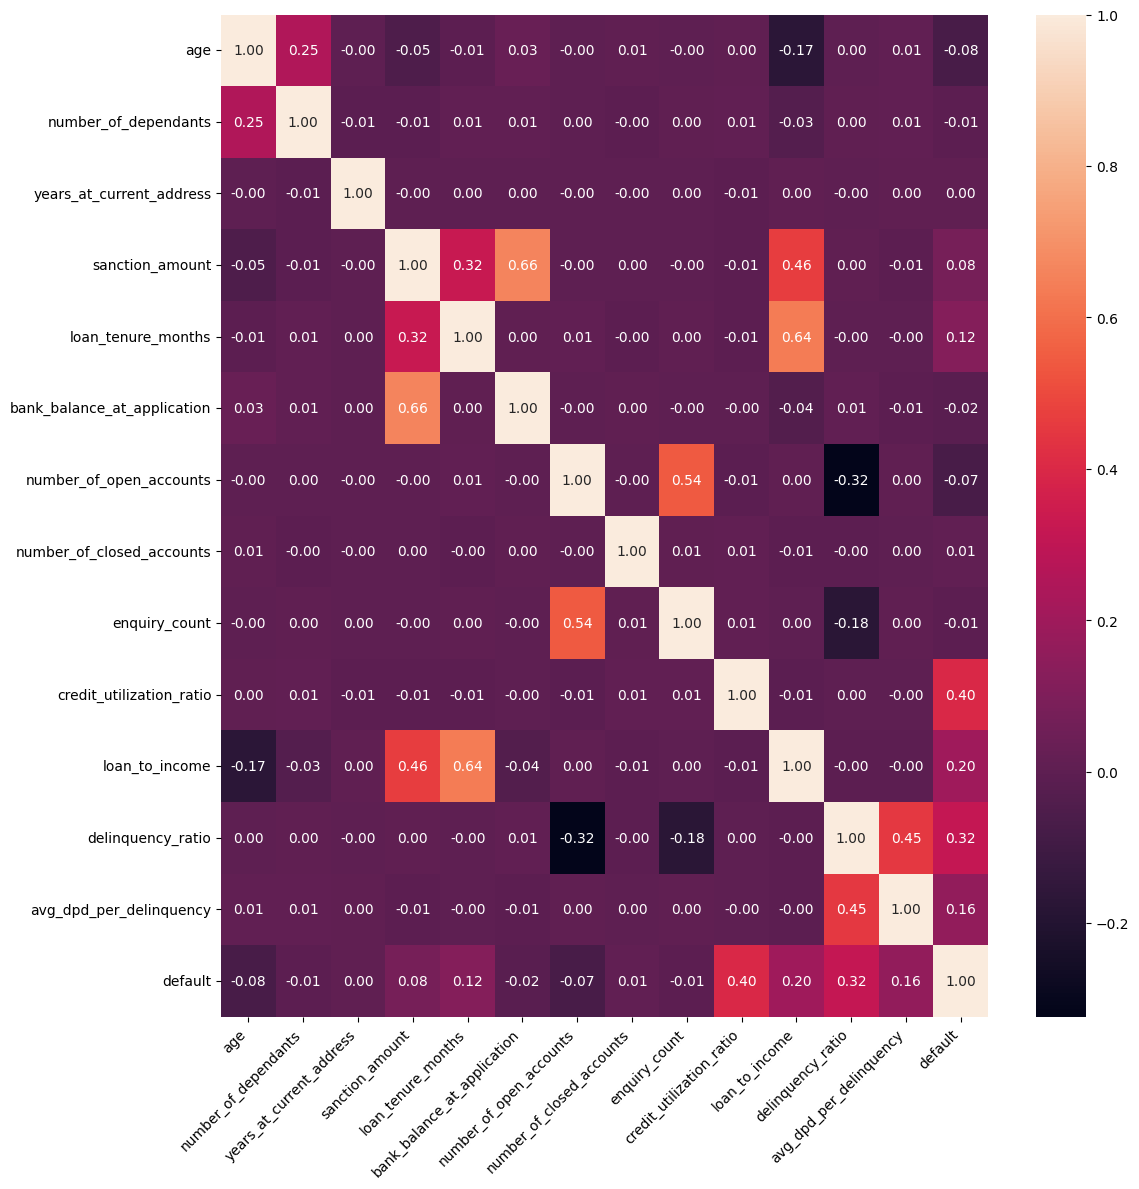

In [674]:
correlationMatrix(df_train[list(selected_numeric_features_vif) + ['default']])

### Scaling

In [675]:
numeric_columns_VIF

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [676]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = numeric_columns_VIF

X_training[cols_to_scale] = scaler.fit_transform(X_training[cols_to_scale])
X_training.describe()

,age,avg_dpd_per_delinquency,bank_balance_at_application,credit_utilization_ratio,delinquency_ratio,enquiry_count,loan_tenure_months,loan_to_income,number_of_closed_accounts,number_of_dependants,number_of_open_accounts,sanction_amount,years_at_current_address
count,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00,37500.00
mean,0.41,0.33,0.13,0.44,0.10,0.50,0.38,0.34,0.50,0.39,0.50,0.09,0.50
std,0.19,0.29,0.13,0.30,0.17,0.25,0.23,0.21,0.41,0.31,0.37,0.12,0.30
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.04,0.18,0.00,0.38,0.19,0.17,0.00,0.00,0.00,0.02,0.23
50%,0.40,0.43,0.08,0.39,0.04,0.50,0.34,0.25,0.50,0.40,0.67,0.05,0.50
75%,0.54,0.57,0.16,0.68,0.13,0.62,0.55,0.54,1.00,0.60,1.00,0.10,0.77
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [677]:
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,avg_dpd_per_delinquency,bank_balance_at_application,credit_utilization_ratio,delinquency_ratio,enquiry_count,loan_tenure_months,loan_to_income,number_of_closed_accounts,number_of_dependants,number_of_open_accounts,sanction_amount,years_at_current_address
count,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00,12500.00
mean,0.42,0.33,0.13,0.44,0.11,0.50,0.38,0.34,0.50,0.38,0.50,0.09,0.50
std,0.19,0.29,0.13,0.30,0.17,0.25,0.23,0.21,0.41,0.31,0.37,0.12,0.30
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.04,0.18,0.00,0.38,0.19,0.17,0.00,0.00,0.00,0.02,0.23
50%,0.42,0.44,0.09,0.39,0.04,0.50,0.34,0.25,0.50,0.40,0.33,0.05,0.50
75%,0.54,0.58,0.16,0.68,0.13,0.62,0.55,0.53,1.00,0.60,0.67,0.10,0.77
max,1.00,1.00,0.94,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.98,1.00


### Categorical columns (IV method)

In [678]:
def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count', 'sum'])
    grouped = grouped.rename(columns={'count': 'total', 'sum': 'good'})
    grouped['bad'] = grouped['total'] - grouped['good']
    
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()
    
    grouped['good_pct'] = grouped['good'] / total_good
    grouped['bad_pct'] = grouped['bad'] / total_bad
    
    grouped['woe'] = np.log(grouped['good_pct'] / grouped['bad_pct'])
    grouped['iv'] = grouped['woe'] * (grouped['good_pct'] - grouped['bad_pct'])
    
    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0)
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    
    total_iv = grouped['iv'].sum()
    
    return (grouped, total_iv)

In [679]:
grouped, total_iv = calculate_woe_iv(pd.concat([X_training, y_training], axis=1), 'loan_purpose', 'default')

print(f'Total IV is {total_iv}')

Total IV is 0.3692189341739988


In [680]:
iv_values = {}

for feature in X_training.columns:
    if(X_training[feature].dtype == 'object'):
        _, iv = calculate_woe_iv(pd.concat([X_training, y_training], axis=1), feature, 'default')
    else:
        X_binned = pd.cut(X_training[feature], bins=10, labels=False)
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_training], axis=1), feature, 'default')
    iv_values[feature] = iv

In [681]:
df_iv = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
df_iv = df_iv.sort_values(by='IV', ascending=False)

In [682]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))
df_iv

,Feature,IV
4,credit_utilization_ratio,2.353
5,delinquency_ratio,0.717
11,loan_to_income,0.477
1,avg_dpd_per_delinquency,0.402
9,loan_purpose,0.369
17,residence_type,0.247
10,loan_tenure_months,0.219
12,loan_type,0.163
18,sanction_amount,0.095
0,age,0.089


In [683]:
iv_threshold = 0.02
selected_features_iv = df_iv[df_iv.IV > iv_threshold].Feature.tolist()
selected_features_iv

['credit_utilization_ratio',
 'delinquency_ratio',
 'loan_to_income',
 'avg_dpd_per_delinquency',
 'loan_purpose',
 'residence_type',
 'loan_tenure_months',
 'loan_type',
 'sanction_amount',
 'age',
 'number_of_open_accounts']

### Feature Encoding

In [684]:
X_training_reduced = X_training[selected_features_iv]
X_test_reduced = X_test[selected_features_iv]

In [685]:
X_training_reduced.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,loan_purpose,residence_type,loan_tenure_months,loan_type,sanction_amount,age,number_of_open_accounts
12746,0.364,0.132,0.453,0.590,Home,Owned,0.415,Secured,0.635,0.788,1.000
32495,0.051,0.062,0.352,0.620,Education,Owned,0.830,Secured,0.023,0.500,0.667
43675,0.000,0.222,0.775,0.558,Home,Mortgage,0.491,Secured,0.219,0.385,0.000
9040,0.879,0.000,0.247,0.000,Education,Mortgage,0.642,Secured,0.045,0.462,0.667
13077,0.717,0.000,0.109,0.000,Personal,Owned,0.170,Unsecured,0.022,0.769,0.000


In [686]:
X_training_reduced_encoded = pd.get_dummies(X_training_reduced, drop_first=True)
X_test_reduced_encoded = pd.get_dummies(X_test_reduced, drop_first=True)

X_training_reduced_encoded.head()

,credit_utilization_ratio,delinquency_ratio,loan_to_income,avg_dpd_per_delinquency,loan_tenure_months,sanction_amount,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
12746,0.364,0.132,0.453,0.590,0.415,0.635,0.788,1.000,False,True,False,True,False,False
32495,0.051,0.062,0.352,0.620,0.830,0.023,0.500,0.667,True,False,False,True,False,False
43675,0.000,0.222,0.775,0.558,0.491,0.219,0.385,0.000,False,True,False,False,False,False
9040,0.879,0.000,0.247,0.000,0.642,0.045,0.462,0.667,True,False,False,False,False,False
13077,0.717,0.000,0.109,0.000,0.170,0.022,0.769,0.000,False,False,True,True,False,True


## Model Training

### Without handling Class Imbalance

In [709]:
X_training_reduced_encoded.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_tenure_months', 'sanction_amount',
       'age', 'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [710]:
from sklearn.linear_model import LogisticRegression

model_LR = LogisticRegression()
model_LR.fit(X_training_reduced_encoded, y_training)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [711]:
from sklearn.metrics import classification_report

y_pred = model_LR.predict(X_test_reduced_encoded)
report = classification_report(y_pred, y_test)

print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11583
           1       0.72      0.85      0.78       917

    accuracy                           0.97     12500
   macro avg       0.86      0.91      0.88     12500
weighted avg       0.97      0.97      0.97     12500



In [712]:
from sklearn.ensemble import RandomForestClassifier

model_RF = RandomForestClassifier()
model_RF.fit(X_training_reduced_encoded, y_training)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [713]:
y_pred = model_RF.predict(X_test_reduced_encoded)
report = classification_report(y_pred, y_test)

print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11616
           1       0.71      0.86      0.78       884

    accuracy                           0.96     12500
   macro avg       0.85      0.92      0.88     12500
weighted avg       0.97      0.96      0.97     12500



In [714]:
from xgboost import XGBClassifier

model_XGB = XGBClassifier()
model_XGB.fit(X_training_reduced_encoded, y_training)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [715]:
y_pred = model_XGB.predict(X_test_reduced_encoded)
report = classification_report(y_pred, y_test)

print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11501
           1       0.77      0.82      0.79       999

    accuracy                           0.97     12500
   macro avg       0.87      0.90      0.89     12500
weighted avg       0.97      0.97      0.97     12500



In [716]:

from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'C': np.logspace (-4, 4, 20), # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg'] # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000) # Increased max_iter for convergence

# Set up RandomizedSearchCV 
random_search= RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1',
    cv=3, # 5-fold cross-validation
    verbose=2,
    random_state=42, # Set a random state for reproducibility
    n_jobs=-1 # Use all available cores
)

# Fit the RandomizedSearchCV to the training data 
random_search.fit(X_training_reduced_encoded, y_training)


# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}") 
print(f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report: ")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'newton-cg', 'C': np.float64(545.5594781168514)}
Best Score: 0.7596050588919017
Classification Report: 
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11426
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12500
   macro avg       0.90      0.86      0.88     12500
weighted avg       0.96      0.96      0.96     12500



In [717]:

from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV 
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0], # L1 regularization term 
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] # L2 regularization term
}
xgb =  XGBClassifier()

random_search= RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100, scoring='f1', 
                                cv=3, verbose=1, n_jobs=-1, random_state=42)
random_search.fit(X_training_reduced_encoded, y_training)

# Print the best parameters and best score
print (f"Best Parameters: {random_search.best_params_}") 
print (f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report:")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'reg_lambda': 1.0, 'reg_alpha': 5.0, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best Score: 0.7915237014051394
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11426
           1       0.78      0.84      0.81      1074

    accuracy                           0.97     12500
   macro avg       0.88      0.91      0.89     12500
weighted avg       0.97      0.97      0.97     12500



### Handling class Imbalance (Undersampling)

In [718]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_training_rus, y_training_rus = rus.fit_resample(X_training_reduced_encoded, y_training)

In [719]:
y_training_rus.value_counts()


default
0    3223
1    3223
Name: count, dtype: int64

In [720]:

from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'C': np.logspace (-4, 4, 20), # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg'] # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000) # Increased max_iter for convergence

# Set up RandomizedSearchCV 
random_search= RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1',
    cv=3, # 5-fold cross-validation
    verbose=2,
    random_state=42, # Set a random state for reproducibility
    n_jobs=-1 # Use all available cores
)

# Fit the RandomizedSearchCV to the training data 
random_search.fit(X_training_rus, y_training_rus)


# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}") 
print(f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report: ")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'liblinear', 'C': np.float64(78.47599703514607)}
Best Score: 0.9351542621960683
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11426
           1       0.54      0.95      0.69      1074

    accuracy                           0.93     12500
   macro avg       0.77      0.94      0.82     12500
weighted avg       0.96      0.93      0.93     12500



In [721]:

from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV 
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0], # L1 regularization term 
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] # L2 regularization term
}
xgb =  XGBClassifier()

random_search= RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100, scoring='f1', 
                                cv=3, verbose=1, n_jobs=-1, random_state=42)
random_search.fit(X_training_rus, y_training_rus)

# Print the best parameters and best score
print (f"Best Parameters: {random_search.best_params_}") 
print (f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report:")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 10.0, 'reg_alpha': 10.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best Score: 0.9466517495748364
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11426
           1       0.53      0.98      0.69      1074

    accuracy                           0.92     12500
   macro avg       0.76      0.95      0.82     12500
weighted avg       0.96      0.92      0.93     12500



### Handling class imbalance (SMOTE)

In [722]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_training_smt, y_training_smt = smt.fit_resample(X_training_reduced_encoded, y_training)

In [723]:
y_training_smt.value_counts()


default
0    34227
1    34227
Name: count, dtype: int64

In [724]:

from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'C': np.logspace (-4, 4, 20), # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg'] # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000) # Increased max_iter for convergence

# Set up RandomizedSearchCV 
random_search= RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled
    scoring='f1',
    cv=3, # 5-fold cross-validation
    verbose=2,
    random_state=42, # Set a random state for reproducibility
    n_jobs=-1 # Use all available cores
)

# Fit the RandomizedSearchCV to the training data 
random_search.fit(X_training_rus, y_training_rus)


# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}") 
print(f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report: ")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'liblinear', 'C': np.float64(78.47599703514607)}
Best Score: 0.9351542621960683
Classification Report: 
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11426
           1       0.54      0.95      0.69      1074

    accuracy                           0.93     12500
   macro avg       0.77      0.94      0.82     12500
weighted avg       0.96      0.93      0.93     12500



In [725]:

from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV 
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0], # L1 regularization term 
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0] # L2 regularization term
}
xgb =  XGBClassifier()

random_search= RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100, scoring='f1', 
                                cv=3, verbose=1, n_jobs=-1, random_state=42)
random_search.fit(X_training_rus, y_training_rus)

# Print the best parameters and best score
print (f"Best Parameters: {random_search.best_params_}") 
print (f"Best Score: {random_search.best_score_}")
best_model = random_search.best_estimator_ 
y_pred = best_model.predict(X_test_reduced_encoded) 
print("Classification Report:")
print(classification_report (y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 10.0, 'reg_alpha': 10.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Best Score: 0.9466517495748364
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96     11426
           1       0.53      0.98      0.69      1074

    accuracy                           0.92     12500
   macro avg       0.76      0.95      0.82     12500
weighted avg       0.96      0.92      0.93     12500



### Handling class imbalance (LR - Optuna)

In [726]:
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [727]:
def objective(trial):
    param = {
        'C': trial.suggest_float("C", 1e-4, 1e4, log=True), #Logarithmaclly spaced values
        'solver': trial.suggest_categorical("solver", ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']), # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True), # Logarithmaclly spaced values
        'class_weight': trial.suggest_categorical('class_weight', [ None, 'balanced']) #Class weights
    }
    model = LogisticRegression(**param, max_iter=1000)
    
    # Calculate the cross-validated f1 score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_training_smt, y_training_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    accuracy = np.mean(scores)
    return accuracy

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50, n_jobs=-1)

print(f'The best parameters are {study_logistic.best_params}')
print(f'Best cross validation score: {study_logistic.best_value}')

[I 2025-08-25 22:35:41,109] A new study created in memory with name: no-name-17413060-abf4-4f1c-8071-0378018da5c6
[I 2025-08-25 22:35:41,367] Trial 0 finished with value: 0.8617707251271401 and parameters: {'C': 0.000627644103829407, 'solver': 'liblinear', 'tol': 0.0019802486289374685, 'class_weight': None}. Best is trial 0 with value: 0.8617707251271401.
[I 2025-08-25 22:35:41,607] Trial 2 finished with value: 0.9134748139217072 and parameters: {'C': 0.001824890009535895, 'solver': 'newton-cg', 'tol': 1.7271310575612582e-05, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.9134748139217072.
[I 2025-08-25 22:35:41,680] Trial 1 finished with value: 0.9461679251000091 and parameters: {'C': 437.8952298383242, 'solver': 'newton-cg', 'tol': 3.019221425261752e-06, 'class_weight': None}. Best is trial 1 with value: 0.9461679251000091.
[I 2025-08-25 22:35:41,784] Trial 3 finished with value: 0.8592731111490188 and parameters: {'C': 89.41641522564021, 'solver': 'newton-cg', 'tol': 0.0

The best parameters are {'C': 1.844952350678706, 'solver': 'saga', 'tol': 0.019663436888113926, 'class_weight': None}
Best cross validation score: 0.9462949715839853


In [728]:
print(f'Best trial: ')
trial = study_logistic.best_trial
print(f'    F1-score: {trial.value}')
print(f'    Params: ')
for key, value in trial.params.items():
    print('     {key} : {value}')

Best trial: 
    F1-score: 0.9462949715839853
    Params: 
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}


In [729]:
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_training_smt, y_training_smt)

,penalty,'l2'
,dual,False
,tol,0.019663436888113926
,C,1.844952350678706
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [730]:
#Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_reduced_encoded)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11426
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12500
   macro avg       0.77      0.94      0.83     12500
weighted avg       0.96      0.93      0.94     12500



### Handling class imbalance (XGBoost - Optuna)

In [731]:

# Define the objective function for Optuna
def objective (trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True), 
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True), 
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0), 
        'max_depth': trial.suggest_int('max_depth', 3, 10), 
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10), 
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), 
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer (f1_score, average='macro')
    scores = cross_val_score (model, X_training_smt, y_training_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    return np.mean(scores)


study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2025-08-25 22:35:45,645] A new study created in memory with name: no-name-d9af80fc-c115-47a8-8c73-3a72c2ea87e3
[I 2025-08-25 22:35:46,268] Trial 0 finished with value: 0.9408820450597201 and parameters: {'lambda': 0.010947019454269754, 'alpha': 0.008348936496682594, 'subsample': 0.6670102499504996, 'colsample_bytree': 0.7866553923157664, 'max_depth': 5, 'eta': 0.028684410126335838, 'gamma': 5.859101085701576, 'scale_pos_weight': 2.3719379934123968, 'min_child_weight': 7, 'max_delta_step': 8}. Best is trial 0 with value: 0.9408820450597201.
[I 2025-08-25 22:35:47,263] Trial 1 finished with value: 0.9665448574848033 and parameters: {'lambda': 0.0912327382614475, 'alpha': 0.8496493607922627, 'subsample': 0.752303940676307, 'colsample_bytree': 0.8969071300617435, 'max_depth': 8, 'eta': 0.06603719241340708, 'gamma': 1.383315501485941, 'scale_pos_weight': 3.6351454100979477, 'min_child_weight': 3, 'max_delta_step': 10}. Best is trial 1 with value: 0.9665448574848033.
[I 2025-08-25 22:35:4

In [732]:
print(f'Best trial: ')
trial = study_xgb.best_trial
print(f'    F1-score: {trial.value}')
print(f'    Params: ')
for key, value in trial.params.items():
    print('     {key} : {value}')

Best trial: 
    F1-score: 0.9763868987917675
    Params: 
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}
     {key} : {value}


In [733]:
best_model_xgb = XGBClassifier(**study_xgb.best_params)
best_model_xgb.fit(X_training_smt, y_training_smt)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9273436377561317
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [734]:
#Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_reduced_encoded)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     11426
           1       0.72      0.86      0.78      1074

    accuracy                           0.96     12500
   macro avg       0.85      0.91      0.88     12500
weighted avg       0.96      0.96      0.96     12500



### Overall Best Model

In [735]:
y_pred = best_model_logistic.predict(X_test_reduced_encoded)

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11426
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12500
   macro avg       0.77      0.94      0.83     12500
weighted avg       0.96      0.93      0.94     12500



## Model Evaluation

### ROC and AUC

In [736]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test_reduced_encoded)[:,1]
probabilities

array([0.50353772, 0.00001747, 0.00674006, ..., 0.00271766, 0.80314536,
       0.60541207], shape=(12500,))

In [737]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
fpr[:10], tpr[:10], thresholds[:10]

(array([0.        , 0.        , 0.        , 0.00008752, 0.00008752,
        0.00017504, 0.00017504, 0.00026256, 0.00026256, 0.00035008]),
 array([0.        , 0.0009311 , 0.16294227, 0.16294227, 0.17039106,
        0.17039106, 0.2132216 , 0.2132216 , 0.22067039, 0.22067039]),
 array([       inf, 1.        , 0.99937103, 0.99936493, 0.99928078,
        0.99925624, 0.99866302, 0.99863913, 0.99847812, 0.99835343]))

In [738]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9835817458369474

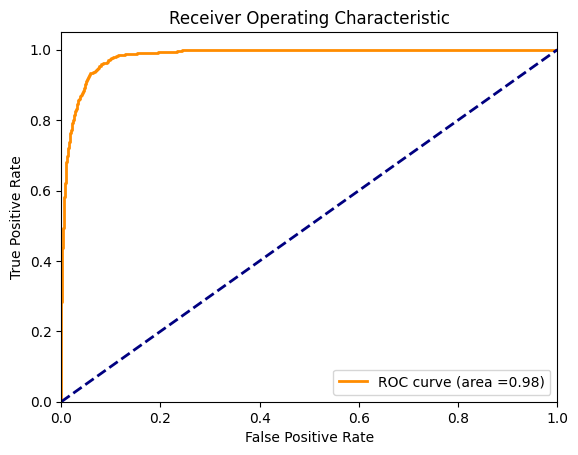

In [760]:
plt.figure()
plt.plot(fpr, tpr, color= 'darkorange', lw=2, label='ROC curve (area =%0.2f)' % area) 
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim ([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc= "lower right")
plt.show()

### Rank order and KS Statistic

In [740]:
probabilities = best_model_logistic.predict_proba(X_test_reduced_encoded)[:,1]
probabilities

array([0.50353772, 0.00001747, 0.00674006, ..., 0.00271766, 0.80314536,
       0.60541207], shape=(12500,))

In [741]:
df_eval = pd.DataFrame({
    'Default Truth': y_test,
    'Default Probability': probabilities,
})

df_eval.head()

,Default Truth,Default Probability
19205,0,0.50
15514,0,0.00
30367,0,0.01
35347,0,0.01
41814,1,0.93


In [742]:
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], 10, labels=False, duplicates='drop')
df_eval.head(3)

,Default Truth,Default Probability,Decile
19205,0,0.50,8
15514,0,0.00,2
30367,0,0.01,6


In [743]:
df_eval = df_eval.sort_values('Default Probability', ascending=False)

In [744]:
df_grouped = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability': x['Default Probability'].min(),
    'Maximum Probability': x['Default Probability'].max(),
    'Events': x['Default Truth'].sum(),
    'Non-events': x['Default Truth'].count() - x['Default Truth'].sum(),    
}))
df_grouped.reset_index(inplace=True)
df_grouped

C:\Users\ahmad\AppData\Local\Temp\ipykernel_30876\2314878715.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_eval.groupby('Decile').apply(lambda x: pd.Series({


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.00,0.00,0.00,1250.00
1,1,0.00,0.00,0.00,1250.00
2,2,0.00,0.00,0.00,1250.00
3,3,0.00,0.00,0.00,1250.00
4,4,0.00,0.00,0.00,1250.00
5,5,0.00,0.00,0.00,1250.00
6,6,0.00,0.03,5.00,1245.00
7,7,0.03,0.22,10.00,1240.00
8,8,0.22,0.82,164.00,1086.00
9,9,0.82,1.00,895.00,355.00


In [745]:
df_grouped = df_grouped.sort_values(by='Decile', ascending=False).reset_index(drop=True)

In [746]:
df_grouped['Event Rate'] = df_grouped['Events']*100 / (df_grouped['Events']+df_grouped['Non-events'])
df_grouped['Non-event Rate'] = df_grouped['Non-events']*100 / (df_grouped['Events']+df_grouped['Non-events'])
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.82,1.00,895.00,355.00,71.60,28.40
1,8,0.22,0.82,164.00,1086.00,13.12,86.88
2,7,0.03,0.22,10.00,1240.00,0.80,99.20
3,6,0.00,0.03,5.00,1245.00,0.40,99.60
4,5,0.00,0.00,0.00,1250.00,0.00,100.00
5,4,0.00,0.00,0.00,1250.00,0.00,100.00
6,3,0.00,0.00,0.00,1250.00,0.00,100.00
7,2,0.00,0.00,0.00,1250.00,0.00,100.00
8,1,0.00,0.00,0.00,1250.00,0.00,100.00
9,0,0.00,0.00,0.00,1250.00,0.00,100.00


In [747]:
df_grouped['Cum Events'] =  df_grouped['Events'].cumsum()
df_grouped['Cum Non-events'] =  df_grouped['Non-events'].cumsum()
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.82,1.00,895.00,355.00,71.60,28.40,895.00,355.00
1,8,0.22,0.82,164.00,1086.00,13.12,86.88,1059.00,1441.00
2,7,0.03,0.22,10.00,1240.00,0.80,99.20,1069.00,2681.00
3,6,0.00,0.03,5.00,1245.00,0.40,99.60,1074.00,3926.00
4,5,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,5176.00
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6426.00
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7676.00
7,2,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,8926.00
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10176.00
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11426.00


In [748]:
df_grouped['Cum Event Rate'] = df_grouped['Cum Events'] * 100 / df_grouped['Events'].sum()
df_grouped['Cum Non-event Rate'] = df_grouped['Cum Non-events']*100 / df_grouped['Non-events'].sum()
df_grouped

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.82,1.00,895.00,355.00,71.60,28.40,895.00,355.00,83.33,3.11
1,8,0.22,0.82,164.00,1086.00,13.12,86.88,1059.00,1441.00,98.60,12.61
2,7,0.03,0.22,10.00,1240.00,0.80,99.20,1069.00,2681.00,99.53,23.46
3,6,0.00,0.03,5.00,1245.00,0.40,99.60,1074.00,3926.00,100.00,34.36
4,5,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,5176.00,100.00,45.30
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6426.00,100.00,56.24
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7676.00,100.00,67.18
7,2,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,8926.00,100.00,78.12
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10176.00,100.00,89.06
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11426.00,100.00,100.00


In [749]:
df_grouped['KS'] = abs(df_grouped['Cum Event Rate'] - df_grouped['Cum Non-event Rate'])
df_grouped 

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.82,1.00,895.00,355.00,71.60,28.40,895.00,355.00,83.33,3.11,80.23
1,8,0.22,0.82,164.00,1086.00,13.12,86.88,1059.00,1441.00,98.60,12.61,85.99
2,7,0.03,0.22,10.00,1240.00,0.80,99.20,1069.00,2681.00,99.53,23.46,76.07
3,6,0.00,0.03,5.00,1245.00,0.40,99.60,1074.00,3926.00,100.00,34.36,65.64
4,5,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,5176.00,100.00,45.30,54.70
5,4,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,6426.00,100.00,56.24,43.76
6,3,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,7676.00,100.00,67.18,32.82
7,2,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,8926.00,100.00,78.12,21.88
8,1,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,10176.00,100.00,89.06,10.94
9,0,0.00,0.00,0.00,1250.00,0.00,100.00,1074.00,11426.00,100.00,100.00,0.00


In [750]:
gini_coefficient = 2 * area - 1

print(f'AUC: {area}')
print(f'Gini Coefficient: {gini_coefficient}')

AUC: 0.9835817458369474
Gini Coefficient: 0.9671634916738947


### Feature Importance

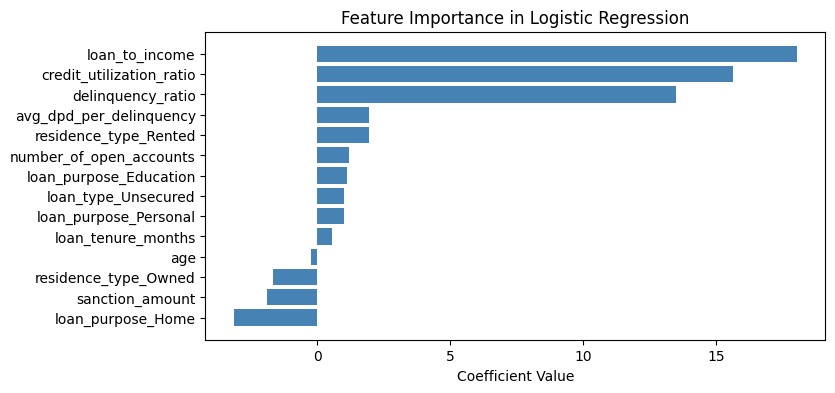

In [751]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_training_reduced_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh (coef_df.index, coef_df['Coefficients'], color='steelblue') 
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

## Export the model

In [752]:
X_test_reduced_encoded.columns

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_tenure_months', 'sanction_amount',
       'age', 'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [754]:
cols_to_scale

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'loan_tenure_months',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency']

In [755]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_training_reduced_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale,
}

In [759]:
model_data['features']

Index(['credit_utilization_ratio', 'delinquency_ratio', 'loan_to_income',
       'avg_dpd_per_delinquency', 'loan_tenure_months', 'sanction_amount',
       'age', 'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [756]:
dump(model_data, 'artifacts/model_data.joblib')

['artifacts/model_data.joblib']

In [757]:
final_model.coef_, final_model.intercept_

(array([[15.64055761, 13.4764214 , 18.05182515,  1.95495712,  0.55350856,
         -1.9155509 , -0.23410116,  1.1794043 ,  1.10156227, -3.15250958,
          0.99517324, -1.6870747 ,  1.92124726,  0.99517324]]),
 array([-21.35764023]))